In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.dates as mdates 

In [3]:
df_model = pd.read_csv("..\\Data\\result.csv")
df_input = pd.read_csv("..\\Data\\model_input.csv")


In [4]:
df_input = df_input.rename(columns={'YYYY':'year', 'MM':'month', 'DD':'day'})

In [5]:
df_input['date'] = pd.to_datetime(
    df_input['year'].astype(str) +
    df_input['month'].astype(str).str.zfill(2) +
    df_input['day'].astype(str).str.zfill(2),
    format='%Y%m%d'
).dt.strftime('%Y%m%d')


In [6]:
df_input = df_input[['year','month', 'day',  'date','Q(mm/d)','TMean(C)','Precip(mm/day)']]

print(len(df_input))
print(df_input.columns.tolist())

10850
['year', 'month', 'day', 'date', 'Q(mm/d)', 'TMean(C)', 'Precip(mm/day)']


In [7]:

df = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", skiprows=1, delimiter=';', decimal=',')
df.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
print(len(df))
df.dropna(inplace=True)
df["Tidspunkt"] = pd.to_datetime(df["Tidspunkt"])
df = df.set_index("Tidspunkt").resample("D").max().reset_index()

209860


In [8]:
df.head()

,Tidspunkt,Vannføring (m³/s)
0,1993-01-01 00:00:00+00:00,6.890178
1,1993-01-02 00:00:00+00:00,6.199734
2,1993-01-03 00:00:00+00:00,6.000031
3,1993-01-04 00:00:00+00:00,5.809420
4,1993-01-05 00:00:00+00:00,5.529519


In [9]:
len(df)

12013

In [10]:
Q_model = df_model['Runoff in Area (m^3/day)'] / 24 / 3600 #discharge in m3/day to compare to observations
len(Q_model)

10850

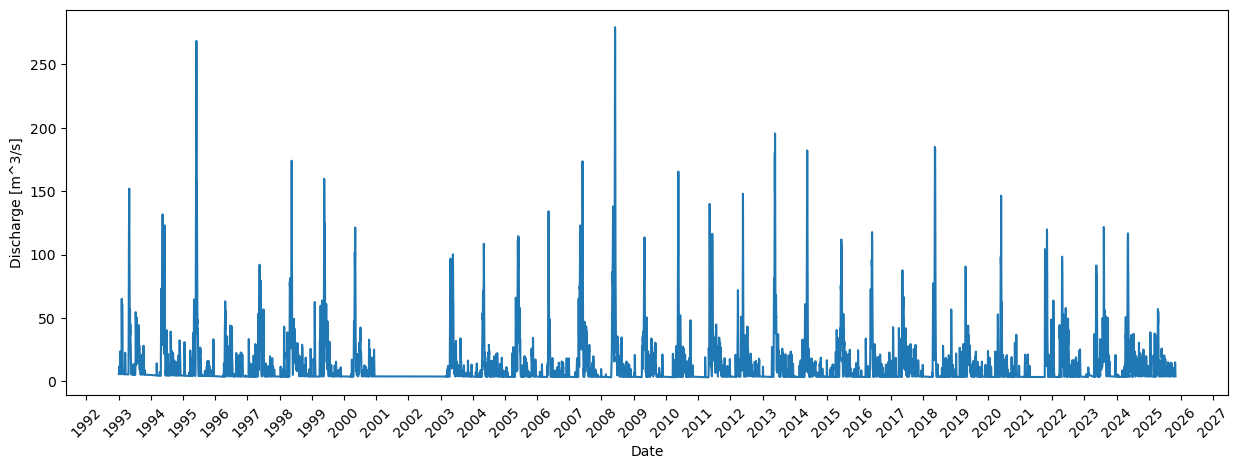

In [11]:
df_input['date'] = pd.to_datetime(df_input['date'])

plt.figure(figsize=(15,5))
plt.plot(df_input['date'], df_model["Runoff in Area (m^3/day)"]/24/3600)


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())         # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # show only year

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Discharge [m^3/s]')
plt.show()


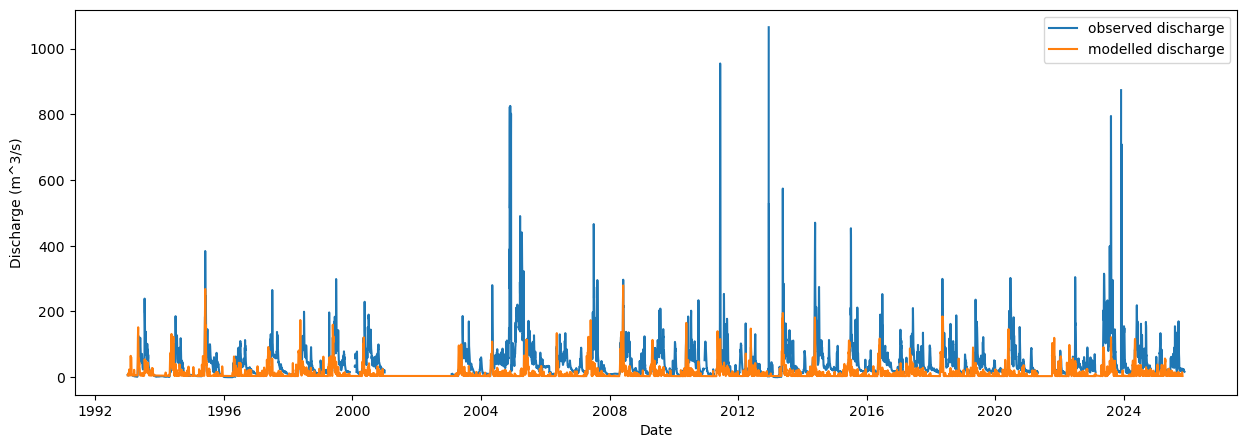

In [12]:
plt.figure(figsize=(15,5))
plt.plot(df['Tidspunkt'], df['Vannføring (m³/s)'], label = 'observed discharge')

plt.plot(df_input['date'], df_model["Runoff in Area (m^3/day)"]/24/3600, label = 'modelled discharge')
plt.xlabel('Date')
plt.ylabel('Discharge (m^3/s)')

plt.legend()
plt.savefig("..\\Figures\\Model_comparison_discharge.png", dpi=300)

In [13]:
print(df_input.columns)
print(df_model.columns)

Index(['year', 'month', 'day', 'date', 'Q(mm/d)', 'TMean(C)',
       'Precip(mm/day)'],
      dtype='object')
Index(['Days', 'Effective Precipitation (mm/day)',
       'Evapotranspiration (mm/day)', 'Actual Evapotranspiration (mm/day)',
       'Storage (mm)', 'Runoff (mm/day)', 'Runoff in Area (m^3/day)'],
      dtype='object')


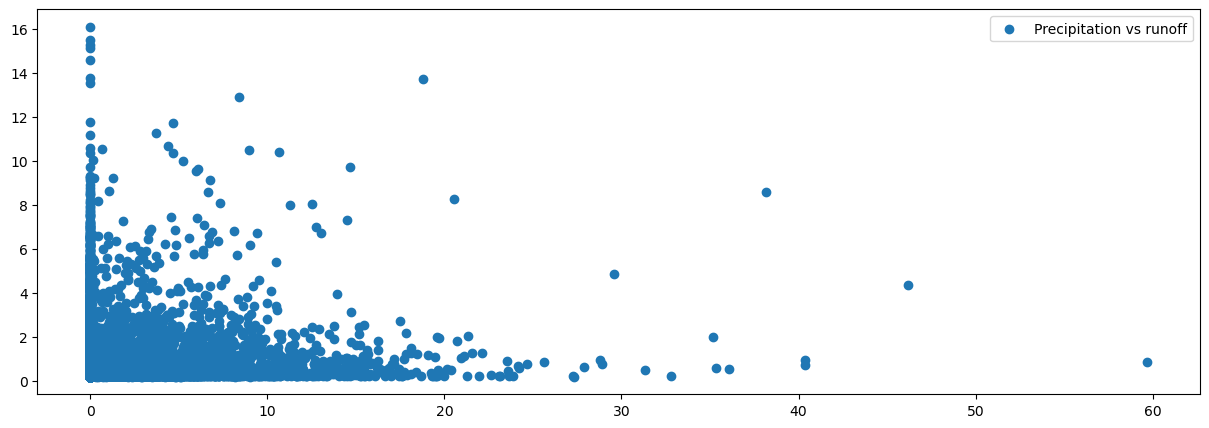

In [14]:
plt.figure(figsize = (15,5))

plt.scatter(df_model['Effective Precipitation (mm/day)'],df_model['Runoff (mm/day)'],  label = 'Precipitation vs runoff')
plt.legend()

In [16]:
import scipy.stats as stats

In [20]:
Qmodel = df_model['Runoff in Area (m^3/day)']/24/3600
Qobs = df['Vannføring (m³/s)']

In [21]:
sorted_Q_model = np.sort(Qmodel)
sorted_Q_obs = np.sort(Qobs)
ecdf_values = np.arange(1, len(sorted_Q_model)+ 1) / len(sorted_Q_model)
ecdf_values_2 = np.arange(1, len(sorted_Q_obs) +1) / len(sorted_Q_obs)

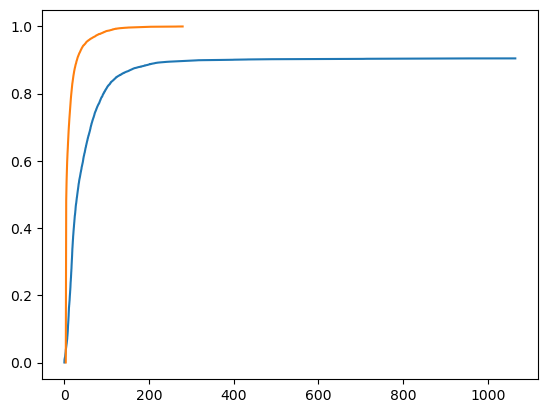

In [23]:
plt.plot(sorted_Q_obs, ecdf_values_2)
plt.plot(sorted_Q_model, ecdf_values)